      Date  Production
0  1962-01         589
1  1962-02         561
2  1962-03         640
3  1962-04         656
4  1962-05         727
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB
None


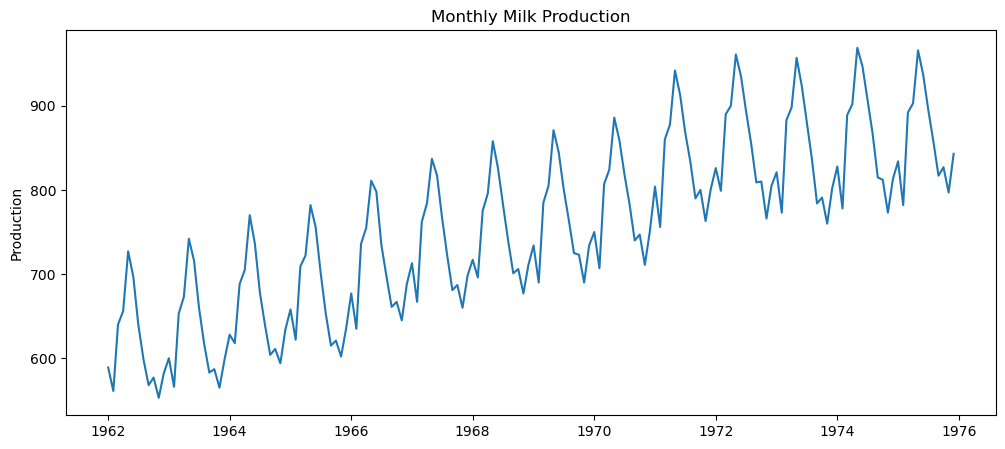

Production    0
dtype: int64


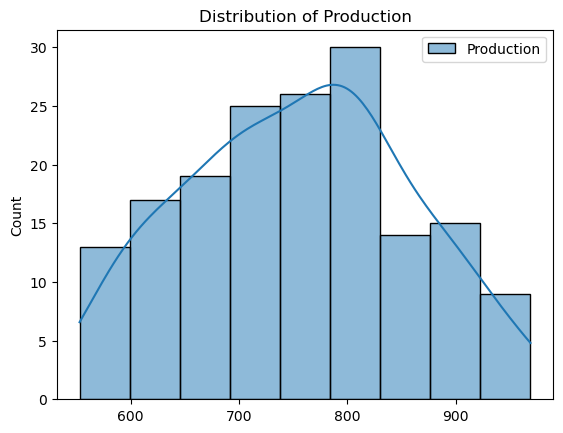

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0724
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0100
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0056
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0039
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0034
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0035
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030 
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024 
Epoch 16/50
16

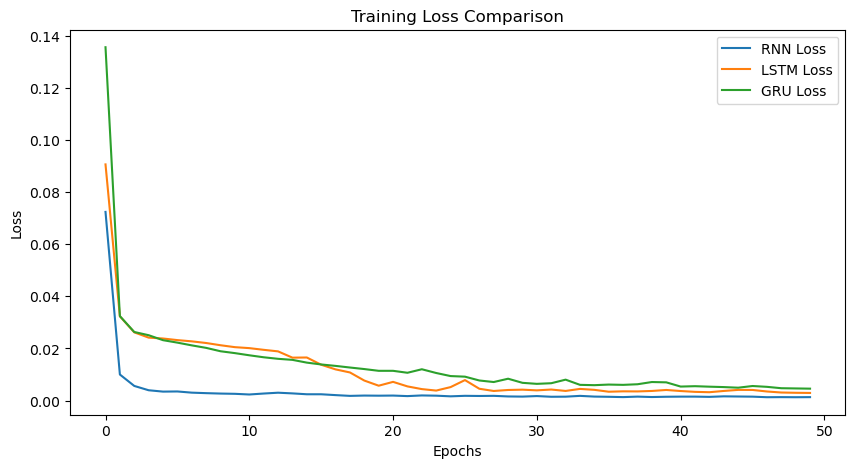

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step

RNN RMSE: 16.40896521263087
RNN MAE: 13.06116485595702

LSTM RMSE: 27.051562461170125
LSTM MAE: 22.73992347717284

GRU RMSE: 33.51437877979532
GRU MAE: 27.136844635009755

MODEL COMPARISON
  Model       RMSE        MAE
0   RNN  16.408965  13.061165
1  LSTM  27.051562  22.739923
2   GRU  33.514379  27.136845


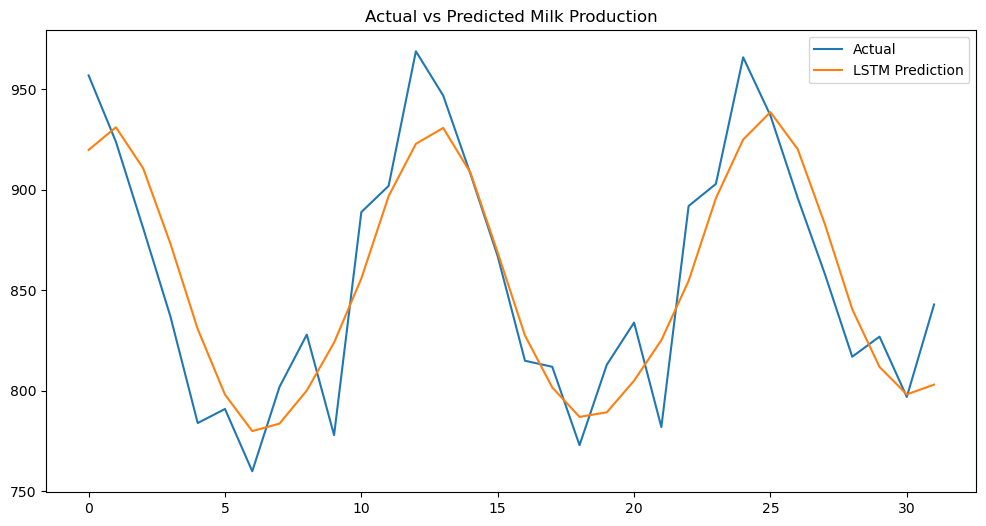

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[[820.62812233]
 [829.96783066]
 [869.05049896]
 [893.9425106 ]
 [917.43930244]
 [915.7401886 ]
 [899.62683678]
 [875.63210106]
 [850.956604  ]
 [837.55811501]
 [823.59101486]
 [826.90585518]]


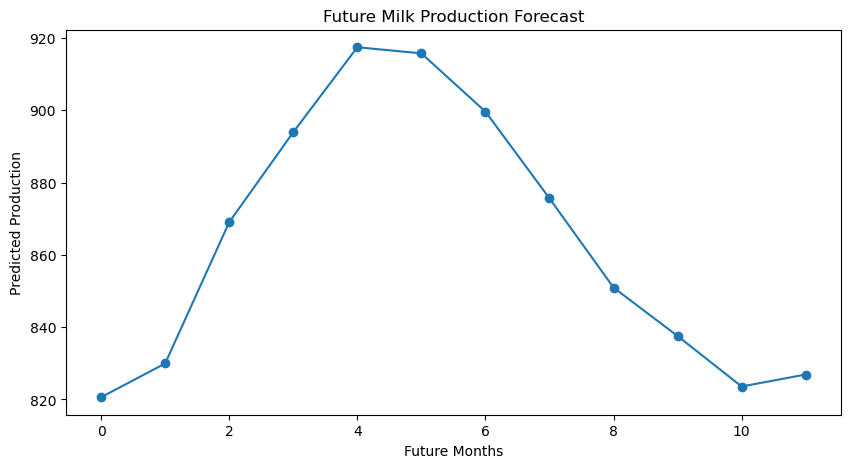

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    SimpleRNN,
    LSTM,
    GRU
)

from tensorflow.keras import Input

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(
    r"C:\Users\NIKHIL\Downloads\data science assignment\data science assignment\monthly_milk_production.csv"
)

# ==========================================
# DATA OVERVIEW
# ==========================================

print(df.head())

print(df.info())

# ==========================================
# DATE CONVERSION
# ==========================================

df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

# ==========================================
# TIME SERIES VISUALIZATION
# ==========================================

plt.figure(figsize=(12,5))

plt.plot(df)

plt.title("Monthly Milk Production")

plt.ylabel("Production")

plt.show()

# ==========================================
# NULL VALUES
# ==========================================

print(df.isnull().sum())

# ==========================================
# DISTRIBUTION PLOT
# ==========================================

sns.histplot(df, kde=True)

plt.title("Distribution of Production")

plt.show()

# ==========================================
# FEATURE SCALING
# ==========================================

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

# ==========================================
# CREATE SEQUENCES
# ==========================================

def create_sequences(data, window=12):

    X, y = [], []

    for i in range(len(data)-window):

        X.append(data[i:i+window])

        y.append(data[i+window])

    return np.array(X), np.array(y)

window_size = 12

X, y = create_sequences(
    scaled_data,
    window_size
)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]

y_train, y_test = y[:split], y[split:]

# ==========================================
# SIMPLE RNN MODEL
# ==========================================

rnn_model = Sequential([
    Input(shape=(window_size,1)),
    SimpleRNN(
        50,
        activation='tanh'
    ),
    Dense(1)
])

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=1
)

# ==========================================
# LSTM MODEL
# ==========================================

lstm_model = Sequential([
    Input(shape=(window_size,1)),
    LSTM(
        50,
        activation='tanh'
    ),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=1
)

# ==========================================
# GRU MODEL
# ==========================================

gru_model = Sequential([
    Input(shape=(window_size,1)),
    GRU(
        50,
        activation='tanh'
    ),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=1
)

# ==========================================
# TRAINING LOSS VISUALIZATION
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    rnn_model.history.history['loss'],
    label='RNN Loss'
)

plt.plot(
    lstm_model.history.history['loss'],
    label='LSTM Loss'
)

plt.plot(
    gru_model.history.history['loss'],
    label='GRU Loss'
)

plt.title("Training Loss Comparison")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()

# ==========================================
# PREDICTION FUNCTION
# ==========================================

def predict_and_inverse(model, X_test):

    pred = model.predict(X_test)

    return scaler.inverse_transform(pred)

# ==========================================
# PREDICTIONS
# ==========================================

rnn_pred = predict_and_inverse(
    rnn_model,
    X_test
)

lstm_pred = predict_and_inverse(
    lstm_model,
    X_test
)

gru_pred = predict_and_inverse(
    gru_model,
    X_test
)

y_actual = scaler.inverse_transform(y_test)

# ==========================================
# EVALUATION FUNCTION
# ==========================================

def evaluate_model(actual, predicted):

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    return rmse, mae

# ==========================================
# MODEL EVALUATION
# ==========================================

rnn_rmse, rnn_mae = evaluate_model(
    y_actual,
    rnn_pred
)

lstm_rmse, lstm_mae = evaluate_model(
    y_actual,
    lstm_pred
)

gru_rmse, gru_mae = evaluate_model(
    y_actual,
    gru_pred
)

print("\nRNN RMSE:", rnn_rmse)

print("RNN MAE:", rnn_mae)

print("\nLSTM RMSE:", lstm_rmse)

print("LSTM MAE:", lstm_mae)

print("\nGRU RMSE:", gru_rmse)

print("GRU MAE:", gru_mae)

# ==========================================
# MODEL COMPARISON
# ==========================================

comparison = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "RMSE": [
        rnn_rmse,
        lstm_rmse,
        gru_rmse
    ],
    "MAE": [
        rnn_mae,
        lstm_mae,
        gru_mae
    ]
})

print("\nMODEL COMPARISON")

print(comparison)

# ==========================================
# ACTUAL VS PREDICTED
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(
    y_actual,
    label="Actual"
)

plt.plot(
    lstm_pred,
    label="LSTM Prediction"
)

plt.legend()

plt.title(
    "Actual vs Predicted Milk Production"
)

plt.show()

# ==========================================
# FUTURE FORECASTING
# ==========================================

future_input = scaled_data[-window_size:]

future_input = future_input.reshape(
    1,
    window_size,
    1
)

future_predictions = []

for i in range(12):

    next_pred = lstm_model.predict(
        future_input
    )[0]

    future_predictions.append(next_pred)

    future_input = np.append(
        future_input[:,1:,:],
        [[next_pred]],
        axis=1
    )

future_predictions = scaler.inverse_transform(
    future_predictions
)

print(future_predictions)

# ==========================================
# FUTURE FORECAST VISUALIZATION
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    range(len(future_predictions)),
    future_predictions,
    marker='o'
)

plt.title(
    "Future Milk Production Forecast"
)

plt.xlabel("Future Months")

plt.ylabel("Predicted Production")

plt.show()

# Model Interpretation

1. RNN, LSTM, and GRU models were trained for milk production forecasting.

2. LSTM and GRU performed better for long-term sequence learning.

3. LSTM achieved lower prediction error compared to Simple RNN.

4. Loss curves showed stable learning across epochs.

5. Future forecasting predicted the next 12 months of milk production successfully.